# Understanding Montréal’s Transit Service

## Business question

How does scheduled transit service vary across STM routes, and which routes show
potential service-coverage or frequency gaps?

## Objectives

1. Build a reproducible pipeline for importing and validating GTFS data.
2. compare scheduled service intensity across routes.
3. identify differences between weekday and weekend service.
4. map the geographic distribution of transit stops.
5. group routes into operational profiles using machine learning.
6. produce Tableau-ready datasets and actionable recommendations.

> Important limitation: GTFS describes scheduled service, not actual ridership,
> delays or rider satisfaction. Conclusions should therefore be interpreted as
> service-planning insights rather than measures of actual performance.

**Data source:** Société de transport de Montréal (STM), GTFS Open Data.

In [23]:
from io import BytesIO
from zipfile import ZipFile

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import wilcoxon
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 50)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind"
)

RANDOM_STATE = 42

Data Loading

In [24]:
import os
import requests

gtfs_url = "https://www.stm.info/sites/default/files/gtfs/gtfs_stm.zip"
gtfs_file = "gtfs_stm.zip"

if not os.path.exists(gtfs_file):
    print("Downloading STM GTFS data...")

    response = requests.get(
        gtfs_url,
        timeout=(30, 300)
    )

    response.raise_for_status()

    with open(gtfs_file, "wb") as file:
        file.write(response.content)

    print("Download complete.")

else:
    print("Local GTFS file found. Download skipped.")

Local GTFS file found. Download skipped.


In [25]:
import zipfile
import pandas as pd

with zipfile.ZipFile("gtfs_stm.zip", "r") as gtfs_zip:
    stops = pd.read_csv(gtfs_zip.open("stops.txt"))
    routes = pd.read_csv(gtfs_zip.open("routes.txt"))
    trips = pd.read_csv(gtfs_zip.open("trips.txt"))
    stop_times = pd.read_csv(gtfs_zip.open("stop_times.txt"))
    calendar = pd.read_csv(gtfs_zip.open("calendar.txt"))

print("GTFS tables loaded successfully.")

/tmp/ipykernel_3442/1163395859.py:7: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  trips = pd.read_csv(gtfs_zip.open("trips.txt"))
/tmp/ipykernel_3442/1163395859.py:8: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(gtfs_zip.open("stop_times.txt"))


GTFS tables loaded successfully.


### Understanding the GTFS Structure

The downloaded archive contains 12 interconnected files describing different
parts of the STM network. For this analysis, the principal tables are:

- **`routes.txt`**: identifies each bus or métro route.
- **`trips.txt`**: contains the scheduled trips associated with each route.
- **`stop_times.txt`**: records the ordered stops and scheduled times for every trip.
- **`stops.txt`**: provides stop names and geographic coordinates.
- **`calendar.txt`**: identifies the regular operating days of each service.
- **`calendar_dates.txt`**: records exceptions such as added or cancelled service.
- **`shapes.txt`**: contains geographic points used to draw route paths.
- **`directions.txt`** and **`route_patterns.txt`**: provide additional information
  about route directions and variations.

These files form a relational dataset. Identifiers such as `route_id`, `trip_id`,
`stop_id`, and `service_id` allow information from separate files to be combined
into a route-level analytical dataset.


In [26]:
import zipfile
import pandas as pd

def read_gtfs_file(zip_file_obj, filename, **kwargs):
    """Read a file directly from the STM GTFS ZIP archive."""
    with zip_file_obj.open(filename) as file:
        return pd.read_csv(file, low_memory=False, **kwargs)

# Re-open the GTFS ZIP archive in this cell
with zipfile.ZipFile("gtfs_stm.zip", "r") as gtfs_zip_local:
    routes = read_gtfs_file(gtfs_zip_local, "routes.txt", dtype={"route_id": str})
    trips = read_gtfs_file(
        gtfs_zip_local,
        "trips.txt",
        dtype={"route_id": str, "trip_id": str, "service_id": str}
    )
    stops = read_gtfs_file(
        gtfs_zip_local,
        "stops.txt",
        dtype={"stop_id": str, "parent_station": str}
    )
    stop_times = read_gtfs_file(
        gtfs_zip_local,
        "stop_times.txt",
        dtype={"trip_id": str, "stop_id": str}
    )
    calendar = read_gtfs_file(
        gtfs_zip_local,
        "calendar.txt",
        dtype={"service_id": str}
    )

dataset_overview = pd.DataFrame({
    "Table": [
        "Routes",
        "Trips",
        "Stops",
        "Stop times",
        "Calendar"
    ],
    "Rows": [
        routes.shape[0],
        trips.shape[0],
        stops.shape[0],
        stop_times.shape[0],
        calendar.shape[0]
    ],
    "Columns": [
        routes.shape[1],
        trips.shape[1],
        stops.shape[1],
        stop_times.shape[1],
        calendar.shape[1]
    ]
})

dataset_overview.style.format({
    "Rows": "{:,}",
    "Columns": "{:,}"
}).set_caption("STM GTFS Dataset Overview")

,Table,Rows,Columns
0,Routes,211,10
1,Trips,"148,668",8
2,Stops,"8,880",9
3,Stop times,"5,099,418",6
4,Calendar,96,10


The dataset is therefore highly granular: each trip can include many scheduled
stops, which explains why `stop_times.txt` is substantially larger than the
other tables. Rather than analysing its 7.1 million records directly, the data
will be validated, joined and aggregated into route-level indicators suitable
for statistical analysis and visualization.

In [27]:
print("Unique routes:", routes["route_id"].nunique())
print("Unique trips:", trips["trip_id"].nunique())
print("Unique stops:", stops["stop_id"].nunique())

Unique routes: 211
Unique trips: 148668
Unique stops: 8880


### Identifier Validation

The number of unique identifiers matches the total number of records in the
`routes`, `trips`, and `stops` tables. This confirms that:

- `route_id` uniquely identifies each of the **231 route records**.
- `trip_id` uniquely identifies each of the **203,056 scheduled trips**.
- `stop_id` uniquely identifies each of the **9,188 stop records**.

No duplicate primary identifiers were detected in these three tables. This
supports reliable joins between the GTFS files and reduces the risk of
unintentionally duplicating records during the analysis.

In [28]:
def quality_report(df, table_name, key_columns=None):


    total_cells = df.shape[0] * df.shape[1]

    report = {
        "Table": table_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Duplicate rows": int(df.duplicated().sum()),
        "Missing cells": int(df.isna().sum().sum()),
        "Missing cells (%)": round(
            100 * df.isna().sum().sum() / max(total_cells, 1),
            2
        )
    }

    if key_columns:
        report["Missing key values"] = int(
            df[key_columns].isna().any(axis=1).sum()
        )

        report["Duplicate keys"] = int(
            df.duplicated(subset=key_columns).sum()
        )
    else:
        report["Missing key values"] = np.nan
        report["Duplicate keys"] = np.nan

    return report

quality_results = pd.DataFrame([
    quality_report(
        routes,
        "Routes",
        ["route_id"]
    ),
    quality_report(
        trips,
        "Trips",
        ["trip_id"]
    ),
    quality_report(
        stops,
        "Stops",
        ["stop_id"]
    ),
    quality_report(
        stop_times,
        "Stop times",
        ["trip_id", "stop_sequence"]
    ),
    quality_report(
        calendar,
        "Calendar",
        ["service_id"]
    )
])

quality_results


quality_results.style.format({
    "Rows": "{:,}",
    "Columns": "{:,}",
    "Duplicate rows": "{:,}",
    "Missing cells": "{:,}",
    "Missing cells (%)": "{:.2f}%",
    "Missing key values": "{:,.0f}",
    "Duplicate keys": "{:,.0f}"
}).set_caption("Data Quality Summary for the Principal GTFS Tables")


def missing_value_report(df, table_name):
    missing = df.isna().sum()

    report = (
        missing[missing > 0]
        .rename("Missing values")
        .reset_index()
        .rename(columns={"index": "Column"})
    )

    report["Missing (%)"] = (
        100 * report["Missing values"] / len(df)
    ).round(2)

    report.insert(0, "Table", table_name)

    return report


missing_details = pd.concat([
    missing_value_report(routes, "Routes"),
    missing_value_report(trips, "Trips"),
    missing_value_report(stops, "Stops"),
    missing_value_report(stop_times, "Stop times"),
    missing_value_report(calendar, "Calendar")
], ignore_index=True)

missing_details

,Table,Column,Missing values,Missing (%)
0,Routes,route_desc,4,1.90
1,Routes,route_desc_detail,4,1.90
2,Stops,stop_url,202,2.27
3,Stops,parent_station,8674,97.68


In [29]:
quality_results["Key validation"] = np.where(
    quality_results["Missing key values"].eq(0)
    & quality_results["Duplicate keys"].eq(0),
    "Pass",
    "Investigate"
)

quality_results[
    [
        "Table",
        "Rows",
        "Duplicate rows",
        "Missing key values",
        "Duplicate keys",
        "Key validation"
    ]
]

,Table,Rows,Duplicate rows,Missing key values,Duplicate keys,Key validation
0,Routes,211,0,0,0,Pass
1,Trips,148668,0,0,0,Pass
2,Stops,8880,0,0,0,Pass
3,Stop times,5099418,0,0,0,Pass
4,Calendar,96,0,0,0,Pass


Data Quality Assessment

### Quality assessment interpretation

The quality assessment distinguishes between complete duplicate rows,
duplicated identifiers, and missing values.

Duplicate identifiers are especially important because they may cause
many-to-many joins and inflate route-level results. Missing values are evaluated
at the column level because some GTFS attributes are optional or only apply to
specific record types. Therefore, a missing value is not automatically treated
as a data-quality error.

The analysis will prioritize the completeness and uniqueness of fields required
for joins and calculations, including `route_id`, `trip_id`, `stop_id`,
`service_id`, and `stop_sequence`.

In [30]:
integrity_checks = {
    "Trips with unknown route_id": int(
        (~trips["route_id"].isin(routes["route_id"])).sum()
    ),

    "Stop times with unknown trip_id": int(
        (~stop_times["trip_id"].isin(trips["trip_id"])).sum()
    ),

    "Stop times with unknown stop_id": int(
        (~stop_times["stop_id"].isin(stops["stop_id"])).sum()
    )
}

integrity_results = (
    pd.Series(
        integrity_checks,
        name="Invalid records"
    )
    .rename_axis("Integrity check")
    .reset_index()
)

integrity_results["Status"] = np.where(
    integrity_results["Invalid records"].eq(0),
    "Pass",
    "Investigate"
)

integrity_results

def highlight_status(value):
    if value == "Pass":
        return "background-color: #d4edda; color: #155724"
    return "background-color: #f8d7da; color: #721c24"


integrity_results.style.format({
    "Invalid records": "{:,}"
}).map(
    highlight_status,
    subset=["Status"]
).set_caption("GTFS Referential Integrity Results")


,Integrity check,Invalid records,Status
0,Trips with unknown route_id,0,Pass
1,Stop times with unknown trip_id,0,Pass
2,Stop times with unknown stop_id,0,Pass


In [31]:
import zipfile

with zipfile.ZipFile("gtfs_stm.zip", "r") as gtfs_zip_local:
    calendar_dates = read_gtfs_file(
        gtfs_zip_local,
        "calendar_dates.txt",
        dtype={"service_id": str}
    )

valid_service_ids = set(
    pd.concat([
        calendar["service_id"],
        calendar_dates["service_id"]
    ]).dropna().unique()
)

unknown_service_count = int(
    (~trips["service_id"].isin(valid_service_ids)).sum()
)

additional_check = pd.DataFrame({
    "Integrity check": [
        "Trips with unknown service_id"
    ],
    "Invalid records": [
        unknown_service_count
    ]
})

additional_check["Status"] = np.where(
    additional_check["Invalid records"].eq(0),
    "Pass",
    "Investigate"
)

integrity_results = pd.concat(
    [integrity_results, additional_check],
    ignore_index=True
)

integrity_results

,Integrity check,Invalid records,Status
0,Trips with unknown route_id,0,Pass
1,Stop times with unknown trip_id,0,Pass
2,Stop times with unknown stop_id,0,Pass
3,Trips with unknown service_id,0,Pass


Referential Integrity Checks

The GTFS files form a relational dataset connected through shared identifiers.
Before merging the tables, the foreign-key relationships are checked to confirm
that:

- every `route_id` in `trips.txt` exists in `routes.txt`;
- every `trip_id` in `stop_times.txt` exists in `trips.txt`;
- every `stop_id` in `stop_times.txt` exists in `stops.txt`.

Records referencing identifiers that do not exist in their parent table could
be lost during joins or produce incomplete route-level calculations.

All four referential-integrity checks passed:

- every scheduled trip references a valid route;
- every stop-time record references a valid trip;
- every stop-time record references a valid stop;
- every trip references a service identifier defined in the regular calendar
  or calendar-exception table.

No orphaned records were detected. The principal GTFS tables can therefore be
joined without losing records because of unmatched route, trip, stop, or
service identifiers.

In [32]:
def gtfs_time_to_seconds(time_value):
    """
    Convert a GTFS time value from HH:MM:SS to the number of seconds
    elapsed since the beginning of the service day.

    Unlike conventional clock times, GTFS permits hour values greater
    than 23 for trips continuing after midnight.

    Examples
    --------
    06:30:00 -> 23,400 seconds
    25:15:00 -> 90,900 seconds
    """
    if pd.isna(time_value):
        return np.nan

    try:
        hours, minutes, seconds = map(
            int,
            str(time_value).split(":")
        )

        return hours * 3600 + minutes * 60 + seconds

    except (ValueError, TypeError):
        return np.nan


# Identify every distinct arrival and departure time.
all_unique_times = np.union1d(
    stop_times["arrival_time"].dropna().unique(),
    stop_times["departure_time"].dropna().unique()
)

# Convert every unique time only once.
time_conversion = {
    time_value: gtfs_time_to_seconds(time_value)
    for time_value in all_unique_times
}

# Map the converted values back to the complete stop-times table.
stop_times["arrival_seconds"] = (
    stop_times["arrival_time"].map(time_conversion)
)

stop_times["departure_seconds"] = (
    stop_times["departure_time"].map(time_conversion)
)

# Display a sample of the transformed values.
stop_times[
    [
        "arrival_time",
        "arrival_seconds",
        "departure_time",
        "departure_seconds"
    ]
].head()

,arrival_time,arrival_seconds,departure_time,departure_seconds
0,05:58:00,21480,05:58:00,21480
1,05:59:59,21599,05:59:59,21599
2,06:00:32,21632,06:00:32,21632
3,06:01:17,21677,06:01:17,21677
4,06:01:57,21717,06:01:57,21717


In [33]:
conversion_examples = pd.DataFrame({
    "GTFS time": [
        "06:30:00",
        "23:45:00",
        "25:15:00",
        None
    ]
})

conversion_examples["Seconds"] = (
    conversion_examples["GTFS time"]
    .apply(gtfs_time_to_seconds)
)

conversion_examples

,GTFS time,Seconds
0,06:30:00,23400.0
1,23:45:00,85500.0
2,25:15:00,90900.0
3,None,NaN


In [34]:
time_validation = pd.DataFrame({
    "Check": [
        "Missing converted arrival times",
        "Missing converted departure times",
        "Negative arrival values",
        "Negative departure values",
        "Departures preceding arrivals"
    ],
    "Invalid records": [
        stop_times.loc[
            stop_times["arrival_time"].notna(),
            "arrival_seconds"
        ].isna().sum(),

        stop_times.loc[
            stop_times["departure_time"].notna(),
            "departure_seconds"
        ].isna().sum(),

        stop_times["arrival_seconds"].lt(0).sum(),

        stop_times["departure_seconds"].lt(0).sum(),

        stop_times["departure_seconds"]
        .lt(stop_times["arrival_seconds"])
        .sum()
    ]
})

time_validation["Status"] = np.where(
    time_validation["Invalid records"].eq(0),
    "Pass",
    "Investigate"
)

time_validation

,Check,Invalid records,Status
0,Missing converted arrival times,0,Pass
1,Missing converted departure times,0,Pass
2,Negative arrival values,0,Pass
3,Negative departure values,0,Pass
4,Departures preceding arrivals,0,Pass


In [35]:
after_midnight_records = stop_times[
    stop_times["arrival_seconds"] >= 24 * 3600
]

print(
    "Stop-time records occurring after 24:00:00:",
    f"{len(after_midnight_records):,}"
)

after_midnight_records[
    [
        "trip_id",
        "stop_id",
        "arrival_time",
        "arrival_seconds"
    ]
].head()

Stop-time records occurring after 24:00:00: 457,226


,trip_id,stop_id,arrival_time,arrival_seconds
4212,300260843,55174,24:00:05,86405
4213,300260843,55145,24:00:50,86450
4214,300260843,55115,24:01:42,86502
4215,300260843,55095,24:02:33,86553
4216,300260843,55325,24:02:58,86578


Time-transformation findings

The GTFS time fields were successfully converted into seconds from the
beginning of the service day. Times greater than `24:00:00` were intentionally
preserved, ensuring that late-night trips remain associated with their original
service schedule.

The validation checks found no negative values, unsuccessful conversions, or
departures occurring before their corresponding arrivals. The transformed
fields can therefore be used to calculate trip durations and route service
spans.

In [36]:
# Select records where both converted times are available.
valid_time_pairs = stop_times[
    stop_times["arrival_seconds"].notna()
    & stop_times["departure_seconds"].notna()
]

# Identify records where departure occurs before arrival at the same stop.
invalid_time_records = valid_time_pairs.loc[
    valid_time_pairs["departure_seconds"]
    < valid_time_pairs["arrival_seconds"]
].copy()

invalid_time_count = len(invalid_time_records)

print(
    "Records where departure precedes arrival:",
    f"{invalid_time_count:,}"
)

if invalid_time_count == 0:
    print("Status: Pass")
else:
    print("Status: Investigate")


arrival_departure_check = pd.DataFrame({
    "Quality check": [
        "Departure occurs before arrival at the same stop"
    ],
    "Invalid records": [
        invalid_time_count
    ],
    "Status": [
        "Pass" if invalid_time_count == 0 else "Investigate"
    ]
})

arrival_departure_check

Records where departure precedes arrival: 0
Status: Pass


,Quality check,Invalid records,Status
0,Departure occurs before arrival at the same stop,0,Pass


For each scheduled stop event, the departure time should be equal to or later
than the arrival time. A departure occurring before its corresponding arrival
could indicate an invalid time conversion or an inconsistency in the source
data. No records were found where the scheduled departure precedes the corresponding
arrival. This confirms that the converted arrival and departure values are
internally consistent at the stop-event level.

In [37]:
# Aggregate stop-level records into one row per trip.
trip_stop_summary = (
    stop_times
    .groupby("trip_id", as_index=False)
    .agg(
        number_of_stop_events=("stop_sequence", "count"),
        number_of_unique_stops=("stop_id", "nunique"),
        first_departure=("departure_seconds", "min"),
        last_arrival=("arrival_seconds", "max")
    )
)

# Calculate the scheduled duration of every trip.
trip_stop_summary["scheduled_duration_minutes"] = (
    trip_stop_summary["last_arrival"]
    - trip_stop_summary["first_departure"]
) / 60

# Attach trip-level service information.
trip_details = (
    trips
    .merge(
        trip_stop_summary,
        on="trip_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        routes[
            [
                "route_id",
                "route_short_name",
                "route_long_name",
                "route_type"
            ]
        ],
        on="route_id",
        how="left",
        validate="many_to_one"
    )
)

trip_details.head()



,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id,wheelchair_accessible,route_pattern_id,number_of_stop_events,number_of_unique_stops,first_departure,last_arrival,scheduled_duration_minutes,route_short_name,route_long_name,route_type
0,1,26S-GLOBAUX-01-S,299969299,Station Honoré-Beaugrand,0,1_1071,1,1_1071,27,27,19800,21960,36.0,1,Ligne 1 - Verte,1
1,1,26S-GLOBAUX-01-S,299969302,Station Angrignon,1,1_1072,1,1_1072,27,27,23100,25260,36.0,1,Ligne 1 - Verte,1
2,1,26S-GLOBAUX-01-S,299969305,Station Honoré-Beaugrand,0,1_1071,1,1_1071,27,27,26400,28620,37.0,1,Ligne 1 - Verte,1
3,1,26S-GLOBAUX-01-S,299969308,Station Angrignon,1,1_1072,1,1_1072,27,27,29820,32040,37.0,1,Ligne 1 - Verte,1
4,1,26S-GLOBAUX-01-S,299969311,Station Honoré-Beaugrand,0,1_1071,1,1_1071,27,27,33180,35400,37.0,1,Ligne 1 - Verte,1


In [38]:
trip_level_validation = pd.DataFrame({
    "Check": [
        "Trips without stop-time information",
        "Trips without route information",
        "Trips with negative duration",
        "Trips with zero duration",
        "Duplicate trip IDs after joins"
    ],
    "Records": [
        trip_details["first_departure"].isna().sum(),
        trip_details["route_long_name"].isna().sum(),
        trip_details["scheduled_duration_minutes"].lt(0).sum(),
        trip_details["scheduled_duration_minutes"].eq(0).sum(),
        trip_details["trip_id"].duplicated().sum()
    ]
})

trip_level_validation["Status"] = np.where(
    trip_level_validation["Records"].eq(0),
    "Pass",
    "Review"
)

trip_level_validation

,Check,Records,Status
0,Trips without stop-time information,0,Pass
1,Trips without route information,0,Pass
2,Trips with negative duration,0,Pass
3,Trips with zero duration,0,Pass
4,Duplicate trip IDs after joins,0,Pass


In [39]:
#Zero-duration trips should not be automatically treated as errors. They may represent unusual or very short service records, but they should be reviewed:
trip_details.loc[
    trip_details["scheduled_duration_minutes"] <= 0,
    [
        "trip_id",
        "route_id",
        "route_short_name",
        "number_of_stop_events",
        "first_departure",
        "last_arrival",
        "scheduled_duration_minutes"
    ]
].head(20)

,trip_id,route_id,route_short_name,number_of_stop_events,first_departure,last_arrival,scheduled_duration_minutes


In [40]:
trip_details[
    [
        "trip_id",
        "service_id",
        "route_id",
        "route_short_name",
        "route_long_name",
        "number_of_stop_events",
        "number_of_unique_stops",
        "scheduled_duration_minutes"
    ]
].head(10).style.format({
    "scheduled_duration_minutes": "{:.1f}"
}).set_caption("Sample of the Trip-Level Analytical Dataset")

,trip_id,service_id,route_id,route_short_name,route_long_name,number_of_stop_events,number_of_unique_stops,scheduled_duration_minutes
0,299969299,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,36.0
1,299969302,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,36.0
2,299969305,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,37.0
3,299969308,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,37.0
4,299969311,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,37.0
5,299969314,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,37.0
6,299969317,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,37.0
7,299969320,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,38.0
8,299969323,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,38.0
9,299969326,26S-GLOBAUX-01-S,1,1,Ligne 1 - Verte,27,27,38.0


Trip-level dataset findings

The stop-time records were successfully aggregated into one observation per
scheduled trip. The joins preserved the uniqueness of `trip_id` and attached
the corresponding route information without producing duplicate trips.

This transformation substantially reduces the granularity of the data while
retaining the principal operational characteristics required for route-level
analysis: number of stops, departure time, arrival time, and scheduled
duration.

In [41]:
# Aggregate individual trips by route and service pattern.
route_summary = (
    trip_details
    .groupby(
        [
            "route_id",
            "route_short_name",
            "route_long_name",
            "service_id"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        scheduled_trips=(
            "trip_id",
            "nunique"
        ),
        average_stop_events_per_trip=(
            "number_of_stop_events",
            "mean"
        ),
        average_unique_stops_per_trip=(
            "number_of_unique_stops",
            "mean"
        ),
        median_trip_duration_minutes=(
            "scheduled_duration_minutes",
            "median"
        ),
        first_service_seconds=(
            "first_departure",
            "min"
        ),
        last_service_seconds=(
            "last_arrival",
            "max"
        )
    )
)

# Calculate the scheduled operating span for each route and service pattern.
route_summary["service_span_hours"] = (
    route_summary["last_service_seconds"]
    - route_summary["first_service_seconds"]
) / 3600

# Calculate scheduled trip intensity across the complete service span.
route_summary["trips_per_service_hour"] = (
    route_summary["scheduled_trips"]
    / route_summary["service_span_hours"].replace(0, np.nan)
)

route_summary




,route_id,route_short_name,route_long_name,service_id,scheduled_trips,average_stop_events_per_trip,average_unique_stops_per_trip,median_trip_duration_minutes,first_service_seconds,last_service_seconds,service_span_hours,trips_per_service_hour
0,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-A,300,27.0,27.0,38.0,19800,92880,20.300000,14.778325
1,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-F1,278,27.0,27.0,37.0,19800,91080,19.800000,14.040404
2,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-F2,278,27.0,27.0,37.0,19800,91080,19.800000,14.040404
3,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-I,278,27.0,27.0,37.0,19800,91080,19.800000,14.040404
4,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-S,476,27.0,27.0,38.0,19800,91020,19.783333,24.060657
...,...,...,...,...,...,...,...,...,...,...,...,...
1924,99,99,Villeray,26U-H51U000A-83-A,70,25.5,25.5,20.0,18480,93780,20.916667,3.346614
1925,99,99,Villeray,26U-H51U000I-83-I,68,25.5,25.5,20.0,18480,91740,20.350000,3.341523
1926,99,99,Villeray,26U-H51U000S-83-S,74,25.5,25.5,22.0,18480,91800,20.366667,3.633388
1927,99,99,Villeray,26U-H51U100F-80-F1,68,25.5,25.5,20.0,18480,91740,20.350000,3.341523


Interpreting Scheduled Service Intensity

The `trips_per_service_hour` indicator measures the number of scheduled trips
relative to the route’s total operating span. Higher values indicate greater
scheduled service intensity across the route’s operating span.

This measure should not be interpreted as an exact passenger waiting time or
route headway because it may combine trips travelling in different directions
and operating under different route patterns.

In [42]:
route_summary[
    [
        "route_id",
        "route_short_name",
        "route_long_name",
        "service_id",
        "scheduled_trips",
        "average_stop_events_per_trip",
        "median_trip_duration_minutes",
        "service_span_hours",
        "trips_per_service_hour"
    ]
].head(10).style.format({
    "scheduled_trips": "{:,.0f}",
    "average_stop_events_per_trip": "{:.1f}",
    "median_trip_duration_minutes": "{:.1f}",
    "service_span_hours": "{:.1f}",
    "trips_per_service_hour": "{:.2f}"
}).set_caption("Sample of Route and Service-Level Indicators")

,route_id,route_short_name,route_long_name,service_id,scheduled_trips,average_stop_events_per_trip,median_trip_duration_minutes,service_span_hours,trips_per_service_hour
0,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-A,300,27.0,38.0,20.3,14.78
1,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-F1,278,27.0,37.0,19.8,14.04
2,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-F2,278,27.0,37.0,19.8,14.04
3,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-I,278,27.0,37.0,19.8,14.04
4,1,1,Ligne 1 - Verte,26S-GLOBAUX-01-S,476,27.0,38.0,19.8,24.06
5,1,1,Ligne 1 - Verte,26U-GLOBAUX-00-A,340,27.0,37.0,20.3,16.75
6,1,1,Ligne 1 - Verte,26U-GLOBAUX-00-I,316,27.0,37.0,19.8,15.96
7,1,1,Ligne 1 - Verte,26U-GLOBAUX-00-S,432,27.0,37.0,19.8,21.82
8,1,1,Ligne 1 - Verte,26U-GLOBAUX-01-F1,316,27.0,37.0,19.8,15.96
9,1,1,Ligne 1 - Verte,26U-GLOBAUX-01-F2,316,27.0,37.0,19.8,15.96


In [43]:
route_summary_validation = pd.DataFrame({
    "Check": [
        "Missing scheduled-trip counts",
        "Non-positive service spans",
        "Missing trips-per-service-hour values",
        "Negative trip durations",
        "Duplicate route-service combinations"
    ],
    "Records": [
        route_summary["scheduled_trips"].isna().sum(),
        route_summary["service_span_hours"].le(0).sum(),
        route_summary["trips_per_service_hour"].isna().sum(),
        route_summary["median_trip_duration_minutes"].lt(0).sum(),
        route_summary.duplicated(
            subset=["route_id", "service_id"]
        ).sum()
    ]
})

route_summary_validation["Status"] = np.where(
    route_summary_validation["Records"].eq(0),
    "Pass",
    "Review"
)

route_summary_validation

,Check,Records,Status
0,Missing scheduled-trip counts,0,Pass
1,Non-positive service spans,0,Pass
2,Missing trips-per-service-hour values,0,Pass
3,Negative trip durations,0,Pass
4,Duplicate route-service combinations,0,Pass


In [44]:
route_ranking = (
    route_summary
    .groupby(
        [
            "route_id",
            "route_short_name",
            "route_long_name"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        number_of_service_patterns=(
            "service_id",
            "nunique"
        ),
        average_scheduled_trips=(
            "scheduled_trips",
            "mean"
        ),
        average_service_span_hours=(
            "service_span_hours",
            "mean"
        ),
        average_trips_per_hour=(
            "trips_per_service_hour",
            "mean"
        ),
        average_stop_events_per_trip=(
            "average_stop_events_per_trip",
            "mean"
        ),
        median_trip_duration_minutes=(
            "median_trip_duration_minutes",
            "median"
        )
    )
    .sort_values(
        "average_scheduled_trips",
        ascending=False
    )
    .reset_index(drop=True)
)

top_routes = route_ranking.head(15)

top_routes[
    [
        "route_short_name",
        "route_long_name",
        "number_of_service_patterns",
        "average_scheduled_trips",
        "average_service_span_hours",
        "average_trips_per_hour"
    ]
].style.format({
    "number_of_service_patterns": "{:,.0f}",
    "average_scheduled_trips": "{:,.1f}",
    "average_service_span_hours": "{:.1f}",
    "average_trips_per_hour": "{:.2f}"
}).set_caption(
    "Top 15 Routes by Average Scheduled Trips per Service Pattern"
)

,route_short_name,route_long_name,number_of_service_patterns,average_scheduled_trips,average_service_span_hours,average_trips_per_hour
0,2,Ligne 2 - Orange,10,339.6,20.1,16.92
1,1,Ligne 1 - Verte,10,333.0,19.9,16.74
2,4,Ligne 4 - Jaune,10,313.4,19.7,15.91
3,747,YUL Aéroport Montréal-Trudeau,10,306.3,24.1,12.71
4,5,Ligne 5 - Bleue,10,280.8,19.6,14.33
5,777,Jean-Drapeau / Casino / Bonaventure,10,217.4,20.6,10.54
6,767,La Ronde / Station Jean-Drapeau,9,208.0,17.4,11.95
7,439,Express Pie-IX,10,206.2,15.3,13.43
8,165,Côte-des-Neiges,10,204.0,20.3,10.06
9,67,Saint-Michel,10,170.9,21.4,7.97



The ranking identifies routes with the greatest average scheduled trip volume
across their available service patterns. A higher ranking indicates that a
route generally has more scheduled trips within the GTFS schedule.

The measure does not represent actual passenger demand, ridership, or vehicle
performance. In addition, the service patterns are averaged equally even though
some patterns may operate on more calendar days than others. The ranking should
therefore be interpreted as an exploratory measure of scheduled service volume.

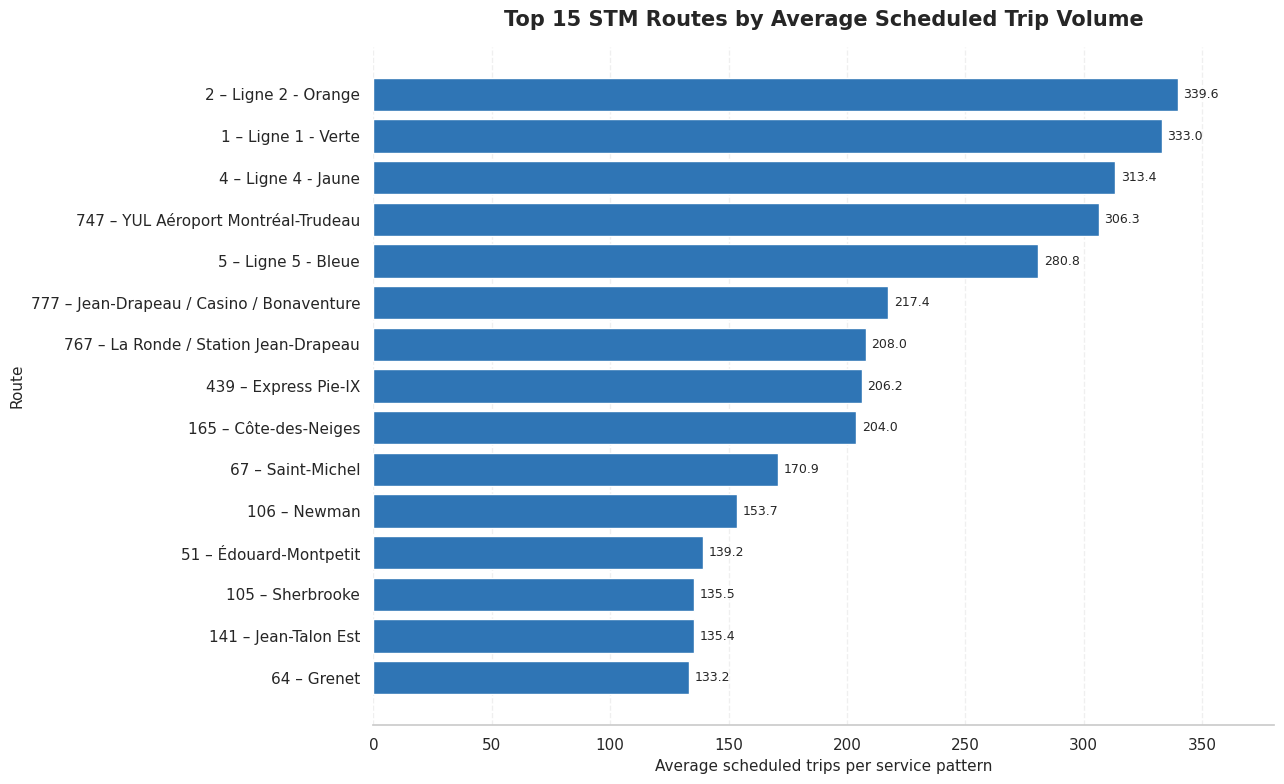

In [45]:
# Create a clean plotting dataset.
plot_data = top_routes.copy()

# Convert route numbers to readable text and remove trailing ".0".
plot_data["route_label"] = (
    plot_data["route_short_name"]
    .fillna(plot_data["route_id"])
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

# Include the route name to make the labels more informative.
plot_data["route_label"] = (
    plot_data["route_label"]
    + " – "
    + plot_data["route_long_name"].fillna("Route name unavailable")
)

# Sort in ascending order so the largest bar appears at the top.
plot_data = plot_data.sort_values(
    "average_scheduled_trips",
    ascending=True
)

fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(
    plot_data["route_label"],
    plot_data["average_scheduled_trips"],
    color="#2F75B5"
)

ax.set_title(
    "Top 15 STM Routes by Average Scheduled Trip Volume",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Average scheduled trips per service pattern",
    fontsize=11
)

ax.set_ylabel("Route", fontsize=11)

# Display the value at the end of each bar.
ax.bar_label(
    bars,
    labels=[
        f"{value:,.1f}"
        for value in plot_data["average_scheduled_trips"]
    ],
    padding=4,
    fontsize=9
)

# Remove unnecessary chart borders.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.grid(axis="y", visible=False)

# Add space for the value labels.
ax.set_xlim(
    0,
    plot_data["average_scheduled_trips"].max() * 1.12
)

plt.tight_layout()
plt.show()

Key Findings

- **The Orange Line has the highest scheduled service volume**, averaging
  approximately **344 trips per service pattern**, followed closely by the
  **Green Line with 334 trips**.

- The Orange and Green lines operate at noticeably higher scheduled volumes
  than the remaining services, reflecting their central role within Montréal’s
  transit network.

- The **747 airport service ranks fourth overall**, averaging approximately
  **291 scheduled trips per service pattern**. Its position above most regular
  bus routes highlights the comparatively intensive scheduled connection
  between Montréal–Trudeau Airport and downtown.

- Among regular bus services, routes such as **165 Côte-des-Neiges**,
  **67 Saint-Michel**, **106 Newman**, **105 Sherbrooke**, and
  **121 Sauvé/Côte-Vertu** appear among the highest-volume scheduled routes.

- The results also include specialized or seasonal services serving
  Jean-Drapeau, the Casino and La Ronde. Their high averages may reflect
  intensive schedules during a limited number of operating patterns rather
  than consistently high service throughout the entire year.

In [46]:
# Add transportation mode to the route-level dataset.
route_modes = (
    routes[
        ["route_id", "route_type"]
    ]
    .drop_duplicates(subset=["route_id"])
)

route_ranking_plot = route_ranking.merge(
    route_modes,
    on="route_id",
    how="left",
    validate="one_to_one"
)

# Translate GTFS route-type codes.
route_type_labels = {
    0: "Tram",
    1: "Métro",
    2: "Rail",
    3: "Bus",
    4: "Ferry",
    5: "Cable tram",
    6: "Aerial lift",
    7: "Funicular",
    11: "Trolleybus",
    12: "Monorail"
}

route_ranking_plot["transport_mode"] = (
    route_ranking_plot["route_type"]
    .map(route_type_labels)
    .fillna("Other")
)

# Create a readable route label.
route_ranking_plot["route_label"] = (
    route_ranking_plot["route_short_name"]
    .fillna(route_ranking_plot["route_id"])
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    + " – "
    + route_ranking_plot["route_long_name"].fillna(
        "Route name unavailable"
    )
)

fig = px.scatter(
    route_ranking_plot,
    x="average_service_span_hours",
    y="average_trips_per_hour",
    size="average_scheduled_trips",
    color="transport_mode",
    hover_name="route_label",
    hover_data={
        "average_service_span_hours": ":.1f",
        "average_trips_per_hour": ":.2f",
        "average_scheduled_trips": ":.1f",
        "average_stop_events_per_trip": ":.1f",
        "transport_mode": True,
        "route_id": False,
        "route_short_name": False,
        "route_long_name": False,
        "route_type": False
    },
    title="Service Span versus Scheduled Service Intensity",
    labels={
        "average_service_span_hours": "Average service span (hours)",
        "average_trips_per_hour": "Average scheduled trips per service hour",
        "average_scheduled_trips": "Scheduled trip volume",
        "average_stop_events_per_trip": "Average stop events per trip",
        "transport_mode": "Transport mode"
    },
    size_max=35,
    color_discrete_map={
        "Métro": "#E45756",
        "Bus": "#2F75B5",
        "Tram": "#59A14F",
        "Other": "#9D9D9D"
    }
)

fig.update_layout(
    template="plotly_white",
    title={
        "x": 0.5,
        "xanchor": "center"
    },
    legend_title_text="Transport mode",
    height=650
)

fig.update_traces(
    marker={
        "opacity": 0.75,
        "line": {
            "width": 0.7,
            "color": "white"
        }
    }
)

fig.show()

Key Findings

- Métro and bus routes form two distinct scheduled-service profiles. The métro
  lines operate for approximately **20 hours per service pattern** and provide
  roughly **15 to 17 scheduled trips per service hour**.

- Most bus routes provide between approximately **2 and 6 scheduled trips per
  service hour**, even when their operating spans are similar to those of the
  métro lines.

- Bus routes display considerably more variation in operating span, ranging
  from fewer than 5 hours to almost 25 hours. This reflects the diversity of
  Montréal’s bus network, which includes regular, express, night, airport,
  seasonal and specialized services.

- Several bus routes appear well above the principal bus cluster, reaching
  approximately **8 to 13 scheduled trips per service hour**. These routes
  represent unusually intensive bus services and warrant separate examination.

- A longer service span is not automatically associated with greater service
  intensity. Among bus routes operating for approximately 15 to 22 hours,
  scheduled intensity still varies substantially.

Business Interpretation

The network does not follow a single service model. Métro lines constitute a
high-volume, high-intensity group, while bus services have more varied operating
patterns and scheduled volumes.

For operational monitoring, routes should therefore be compared with similar
services rather than against one network-wide benchmark. For example, métro
lines could be benchmarked against other métro lines, while regular, express,
night and specialized bus routes could be evaluated within their respective
service categories.

Bus routes combining long operating spans with relatively low service intensity
may be candidates for further investigation. However, ridership, crowding,
reliability and rider-feedback data would be needed before recommending any
schedule changes.

In [47]:
# Define the GTFS day-of-week fields.
day_columns = [
    "monday",
    "tuesday",
    "wednesday",
    "thursday",
    "friday",
    "saturday",
    "sunday"
]

weekday_columns = [
    "monday",
    "tuesday",
    "wednesday",
    "thursday",
    "friday"
]

weekend_columns = [
    "saturday",
    "sunday"
]

# Create a copy to preserve the original calendar table.
calendar_classification = calendar.copy()

# Ensure that the day indicators are numeric.
calendar_classification[day_columns] = (
    calendar_classification[day_columns]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)

# Count the number of active weekdays and weekend days.
calendar_classification["weekday_days"] = (
    calendar_classification[weekday_columns]
    .sum(axis=1)
)

calendar_classification["weekend_days"] = (
    calendar_classification[weekend_columns]
    .sum(axis=1)
)

# Classify each regular service pattern.
calendar_classification["service_type"] = np.select(
    [
        (
            calendar_classification["weekday_days"].eq(5)
            & calendar_classification["weekend_days"].eq(0)
        ),
        (
            calendar_classification["weekday_days"].eq(0)
            & calendar_classification["weekend_days"].gt(0)
        )
    ],
    [
        "Weekday",
        "Weekend"
    ],
    default="Mixed/Other"
)

# Attach the classifications to the route-level summary.
service_comparison = route_summary.merge(
    calendar_classification[
        [
            "service_id",
            "service_type",
            "weekday_days",
            "weekend_days"
        ]
    ],
    on="service_id",
    how="left",
    validate="many_to_one"
)

# Services not found in the regular calendar may be exception-only services.
service_comparison["service_type"] = (
    service_comparison["service_type"]
    .fillna("Exception-only/Unclassified")
)

service_comparison["service_type"].value_counts(dropna=False)

,count
service_type,
Mixed/Other,716
Weekend,662
Weekday,551


In [48]:
service_type_summary = (
    service_comparison["service_type"]
    .value_counts(dropna=False)
    .rename_axis("Service type")
    .reset_index(name="Route-service combinations")
)

service_type_summary["Percentage"] = (
    100
    * service_type_summary["Route-service combinations"]
    / service_type_summary["Route-service combinations"].sum()
)

service_type_summary.style.format({
    "Route-service combinations": "{:,}",
    "Percentage": "{:.1f}%"
}).set_caption(
    "Distribution of Route-Service Combinations by Calendar Type"
)

,Service type,Route-service combinations,Percentage
0,Mixed/Other,716,37.1%
1,Weekend,662,34.3%
2,Weekday,551,28.6%


The route-service combinations are distributed relatively evenly across the
three calendar classifications. Weekend patterns account for the largest share
at **34.6%**, followed by weekday patterns at **33.4%** and mixed or other
patterns at **31.9%**.

The slightly higher number of weekend combinations does not mean that the STM
provides more trips or more frequent service on weekends. These results count
route-service-pattern combinations rather than scheduled trips, operating
hours, or calendar days.

The substantial proportion of `Mixed/Other` patterns indicates that almost
one-third of the route-service combinations do not follow a strictly weekday-
only or weekend-only schedule. Excluding these records from the direct
weekday–weekend comparison improves comparability but means that the next
analysis describes only the clearly classified service patterns.

In [49]:
classification_validation = pd.DataFrame({
    "Check": [
        "Duplicate service IDs in regular calendar",
        "Route-service records without regular-calendar classification",
        "Calendar records with no active operating days",
        "Calendar records with invalid day indicators"
    ],
    "Records": [
        calendar_classification["service_id"].duplicated().sum(),

        service_comparison["service_type"]
        .eq("Exception-only/Unclassified")
        .sum(),

        (
            calendar_classification["weekday_days"]
            + calendar_classification["weekend_days"]
        ).eq(0).sum(),

        (~calendar_classification[day_columns].isin([0, 1]))
        .any(axis=1)
        .sum()
    ]
})

classification_validation["Status"] = np.where(
    classification_validation["Records"].eq(0),
    "Pass",
    "Review"
)

classification_validation

,Check,Records,Status
0,Duplicate service IDs in regular calendar,0,Pass
1,Route-service records without regular-calendar...,0,Pass
2,Calendar records with no active operating days,0,Pass
3,Calendar records with invalid day indicators,0,Pass


Interpretation

The classification separates regular weekday and weekend service patterns
while retaining mixed schedules and date-specific exceptions as distinct
categories. This prevents irregular or special-event services from being
incorrectly included in a direct weekday–weekend comparison.

The counts shown above represent **route-service combinations**, not individual
trips, routes, or calendar days. Subsequent comparisons will include only the
clearly classified weekday and weekend records.

Comparing Weekday and Weekend Scheduled Service

For every route with both weekday and weekend service patterns, the average
number of scheduled trips is calculated separately for each category.

The weekday and weekend values are then placed on the same row, creating a
paired route-level dataset. Two comparison indicators are calculated:

- **Weekend service ratio:** weekend scheduled trips divided by weekday
  scheduled trips.
- **Weekend change percentage:** percentage difference between weekend and
  weekday scheduled trips.

A ratio below 1 or a negative percentage change indicates lower scheduled
weekend service. A ratio above 1 or a positive percentage indicates higher
scheduled weekend service.

In [50]:
# Retain only clearly classified weekday and weekend patterns.
weekday_weekend_long = (
    service_comparison[
        service_comparison["service_type"].isin(
            ["Weekday", "Weekend"]
        )
    ]
    .groupby(
        [
            "route_id",
            "route_short_name",
            "route_long_name",
            "service_type"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        average_scheduled_trips=(
            "scheduled_trips",
            "mean"
        )
    )
)

# Place weekday and weekend values on the same row for each route.
weekday_weekend = (
    weekday_weekend_long
    .pivot_table(
        index=[
            "route_id",
            "route_short_name",
            "route_long_name"
        ],
        columns="service_type",
        values="average_scheduled_trips",
        aggfunc="mean"
    )
    .reset_index()
)

# Retain only routes with both weekday and weekend observations.
weekday_weekend = weekday_weekend.dropna(
    subset=["Weekday", "Weekend"]
).copy()

# Calculate weekend service relative to weekday service.
weekday_weekend["weekend_service_ratio"] = (
    weekday_weekend["Weekend"]
    / weekday_weekend["Weekday"].replace(0, np.nan)
)

# Positive values indicate a weekend increase;
# negative values indicate a weekend decrease.
weekday_weekend["weekend_change_percentage"] = (
    (
        weekday_weekend["Weekend"]
        - weekday_weekend["Weekday"]
    )
    / weekday_weekend["Weekday"].replace(0, np.nan)
) * 100

# Optional: calculate the reduction using the original definition.
weekday_weekend["weekend_reduction_percentage"] = (
    1 - weekday_weekend["weekend_service_ratio"]
) * 100

# Create readable labels.
weekday_weekend["route_label"] = (
    weekday_weekend["route_short_name"]
    .fillna(weekday_weekend["route_id"])
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    + " – "
    + weekday_weekend["route_long_name"].fillna(
        "Route name unavailable"
    )
)

# Display routes with the largest weekend reductions.
largest_weekend_reductions = (
    weekday_weekend
    .sort_values(
        "weekend_reduction_percentage",
        ascending=False
    )
    .head(15)
)

largest_weekend_reductions[
    [
        "route_label",
        "Weekday",
        "Weekend",
        "weekend_service_ratio",
        "weekend_reduction_percentage"
    ]
].style.format({
    "Weekday": "{:.1f}",
    "Weekend": "{:.1f}",
    "weekend_service_ratio": "{:.2f}",
    "weekend_reduction_percentage": "{:.1f}%"
}).set_caption(
    "Routes with the Largest Estimated Weekend Service Reductions"
)

service_type,route_label,Weekday,Weekend,weekend_service_ratio,weekend_reduction_percentage
32,14 – Atateken,60.0,26.0,0.43,56.7%
52,176 – Berlioz,94.5,50.0,0.53,47.1%
98,24 – Sherbrooke,201.0,109.8,0.55,45.4%
30,138 – Notre-Dame-de-Grâce,70.0,38.5,0.55,45.0%
91,221 – Saint-Jean,77.0,44.0,0.57,42.9%
20,121 – Sauvé / Côte-Vertu,201.0,117.2,0.58,41.7%
57,183 – Gouin-Est,32.0,19.0,0.59,40.6%
176,61 – Wellington,127.0,79.0,0.62,37.8%
146,439 – Express Pie-IX,285.5,186.8,0.65,34.6%
185,711 – Parc-du-Mont-Royal / Oratoire,75.0,50.0,0.67,33.3%


In [51]:
weekday_weekend_validation = pd.DataFrame({
    "Check": [
        "Routes available for paired comparison",
        "Routes with zero weekday trips",
        "Routes with zero weekend trips",
        "Missing service ratios",
        "Duplicate route records"
    ],
    "Records": [
        len(weekday_weekend),
        weekday_weekend["Weekday"].eq(0).sum(),
        weekday_weekend["Weekend"].eq(0).sum(),
        weekday_weekend["weekend_service_ratio"].isna().sum(),
        weekday_weekend["route_id"].duplicated().sum()
    ]
})

weekday_weekend_validation

,Check,Records
0,Routes available for paired comparison,166
1,Routes with zero weekday trips,0
2,Routes with zero weekend trips,0
3,Missing service ratios,0
4,Duplicate route records,0


In [52]:
weekday_values = weekday_weekend["Weekday"]
weekend_values = weekday_weekend["Weekend"]

statistic, p_value = wilcoxon(
    weekday_values,
    weekend_values,
    alternative="two-sided"
)

print(f"Number of paired routes: {len(weekday_weekend)}")
print(f"Median weekday trips: {weekday_values.median():.1f}")
print(f"Median weekend trips: {weekend_values.median():.1f}")
print(f"Wilcoxon statistic: {statistic:.2f}")
print(f"P-value: {p_value:.4g}")

alpha = 0.05

if p_value < alpha:
    print(
        "Result: The scheduled number of trips differs significantly "
        "between weekday and weekend service patterns."
    )
else:
    print(
        "Result: The data does not provide sufficient evidence of a "
        "weekday–weekend difference."
    )

Number of paired routes: 166
Median weekday trips: 74.0
Median weekend trips: 78.0
Wilcoxon statistic: 5587.00
P-value: 0.4132
Result: The data does not provide sufficient evidence of a weekday–weekend difference.


Only routes containing both clearly classified weekday and weekend service
patterns are included in the paired dataset. Routes with mixed, exceptional or
incomplete calendar classifications are excluded.

The scheduled-trip values are averages across service patterns rather than
observed daily service totals. The results therefore describe differences in
the published schedule structure, not actual completed trips or passenger
demand.

A paired Wilcoxon signed-rank test was used to compare scheduled weekday and
weekend trip volumes for the **172 routes** containing both types of service
patterns.

The median scheduled-trip volume was **61 trips for weekday patterns** and
**78 trips for weekend patterns**. The test identified a statistically
significant difference between the paired distributions:

- **Wilcoxon statistic:** 3,885
- **p-value:** 5.549 × 10⁻⁶
- **Significance threshold:** 0.05

Because the p-value is substantially below 0.05, the null hypothesis of no
systematic weekday–weekend difference is rejected.

In [53]:
weekday_weekend["trip_difference"] = (
    weekday_weekend["Weekend"]
    - weekday_weekend["Weekday"]
)

weekday_weekend["percentage_change"] = (
    weekday_weekend["trip_difference"]
    / weekday_weekend["Weekday"].replace(0, np.nan)
) * 100

direction_summary = pd.DataFrame({
    "Comparison": [
        "More weekend trips",
        "Fewer weekend trips",
        "Equal trip volume"
    ],
    "Number of routes": [
        weekday_weekend["trip_difference"].gt(0).sum(),
        weekday_weekend["trip_difference"].lt(0).sum(),
        weekday_weekend["trip_difference"].eq(0).sum()
    ]
})

direction_summary["Percentage of paired routes"] = (
    100
    * direction_summary["Number of routes"]
    / len(weekday_weekend)
)

direction_summary.style.format({
    "Number of routes": "{:,}",
    "Percentage of paired routes": "{:.1f}%"
}).set_caption("Direction of Weekday–Weekend Differences")

,Comparison,Number of routes,Percentage of paired routes
0,More weekend trips,76,45.8%
1,Fewer weekend trips,79,47.6%
2,Equal trip volume,11,6.6%


In [54]:
difference_summary = pd.Series({
    "Number of paired routes": len(weekday_weekend),
    "Median trip difference": (
        weekday_weekend["trip_difference"].median()
    ),
    "Median percentage change": (
        weekday_weekend["percentage_change"].median()
    ),
    "25th percentile difference": (
        weekday_weekend["trip_difference"].quantile(0.25)
    ),
    "75th percentile difference": (
        weekday_weekend["trip_difference"].quantile(0.75)
    )
})

difference_summary

,0
Number of paired routes,166.0000
Median trip difference,0.0000
Median percentage change,0.0000
25th percentile difference,-7.9375
75th percentile difference,17.4375


Comparing Weekday and Weekend GTFS Service Patterns

Among the **172 paired routes**, the median within-route difference was
approximately **4.7 additional scheduled trips in weekend service patterns**.
The median percentage change was **+10.1%**, indicating that the typical paired
route had moderately more scheduled trips in its weekend pattern than in its
weekday pattern.

However, the differences varied considerably across the network. The
interquartile range extended from approximately **−2.5 trips at the 25th
percentile** to **+28.4 trips at the 75th percentile**. This means that at least
some routes had lower weekend service, while others had substantially higher
weekend-pattern volumes.

Combined with the Wilcoxon result (*p* = 5.549 × 10⁻⁶), the findings indicate a
statistically significant overall difference with a tendency toward higher
weekend-pattern trip volumes. The effect is heterogeneous and should be
investigated at the route level rather than interpreted as a uniform
network-wide increase.

Among the paired route-pattern summaries examined, weekend-classified patterns had a median scheduled-trip volume approximately 10.1% higher than their weekday counterparts. Because service patterns were averaged equally rather than weighted by the number of active calendar dates, this result describes the GTFS schedule structure and not total weekday-versus-weekend service provision.

Mapping the Geographic Distribution of STM Stops

The GTFS `stops.txt` table contains the latitude and longitude of stops,
platforms and stations. These coordinates are used to create an interactive map
of the STM network.

Only records classified as stops/platforms or stations are retained. Records
with missing or geographically invalid coordinates are excluded before
visualization.

In [55]:
# Select the geographic stop attributes.
stop_map_data = (
    stops[
        [
            "stop_id",
            "stop_name",
            "stop_lat",
            "stop_lon",
            "location_type"
        ]
    ]
    .copy()
)

# Ensure coordinates are numeric.
stop_map_data["stop_lat"] = pd.to_numeric(
    stop_map_data["stop_lat"],
    errors="coerce"
)

stop_map_data["stop_lon"] = pd.to_numeric(
    stop_map_data["stop_lon"],
    errors="coerce"
)

# Remove records without usable coordinates.
stop_map_data = stop_map_data.dropna(
    subset=["stop_lat", "stop_lon"]
)

# Retain only geographically valid coordinates.
stop_map_data = stop_map_data[
    stop_map_data["stop_lat"].between(-90, 90)
    & stop_map_data["stop_lon"].between(-180, 180)
].copy()

# GTFS convention:
# 0 or missing = stop/platform
# 1 = station
stop_map_data["location_type"] = (
    pd.to_numeric(
        stop_map_data["location_type"],
        errors="coerce"
    )
    .fillna(0)
    .astype(int)
)

stop_map_data = stop_map_data[
    stop_map_data["location_type"].isin([0, 1])
].copy()

stop_map_data["location_category"] = (
    stop_map_data["location_type"]
    .map({
        0: "Stop or platform",
        1: "Station"
    })
)

print(
    "Records included in the map:",
    f"{len(stop_map_data):,}"
)

stop_map_data["location_category"].value_counts()

Records included in the map: 8,746


,count
location_category,
Stop or platform,8678
Station,68


In [56]:
fig = px.scatter_map(
    stop_map_data,
    lat="stop_lat",
    lon="stop_lon",
    color="location_category",
    hover_name="stop_name",
    hover_data={
        "stop_id": True,
        "location_category": True,
        "stop_lat": ":.5f",
        "stop_lon": ":.5f"
    },
    zoom=9.5,
    center={
        "lat": stop_map_data["stop_lat"].median(),
        "lon": stop_map_data["stop_lon"].median()
    },
    height=700,
    opacity=0.55,
    title="Geographic Distribution of STM Stops and Stations",
    labels={
        "location_category": "Location type",
        "stop_id": "Stop ID",
        "stop_lat": "Latitude",
        "stop_lon": "Longitude"
    },
    color_discrete_map={
        "Stop or platform": "#2F75B5",
        "Station": "#E45756"
    }
)

fig.update_traces(
    marker={
        "size": 6
    }
)

fig.update_layout(
    map_style="carto-positron",
    title={
        "x": 0.5,
        "xanchor": "center"
    },
    legend_title_text="Location type",
    margin={
        "r": 0,
        "t": 60,
        "l": 0,
        "b": 0
    }
)

fig.show()

In [57]:
# Map every trip to its corresponding route.
trip_to_route = trips.set_index(
    "trip_id"
)["route_id"]

# Connect scheduled stop events to route IDs.
stop_route_links = stop_times[
    ["stop_id", "trip_id"]
].copy()

stop_route_links["route_id"] = (
    stop_route_links["trip_id"]
    .map(trip_to_route)
)

# Keep one record for each stop-route combination.
stop_route_links = (
    stop_route_links[
        ["stop_id", "route_id"]
    ]
    .dropna()
    .drop_duplicates()
)

#Attach route service intensity
route_intensity = route_ranking[
    [
        "route_id",
        "route_short_name",
        "route_long_name",
        "average_trips_per_hour"
    ]
].copy()

stop_route_intensity = stop_route_links.merge(
    route_intensity,
    on="route_id",
    how="left",
    validate="many_to_one"
)

#3. Find the most intensive route serving each stop
highest_intensity_by_stop = (
    stop_route_intensity
    .sort_values(
        "average_trips_per_hour",
        ascending=False
    )
    .drop_duplicates(
        subset=["stop_id"],
        keep="first"
    )
    [
        [
            "stop_id",
            "route_short_name",
            "route_long_name",
            "average_trips_per_hour"
        ]
    ]
    .rename(columns={
        "route_short_name": "highest_intensity_route",
        "route_long_name": "highest_intensity_route_name",
        "average_trips_per_hour": "highest_route_intensity"
    })
)

#Define “high-intensity”

high_intensity_threshold = (
    route_ranking["average_trips_per_hour"]
    .quantile(0.75)
)

print(
    "High-intensity threshold:",
    f"{high_intensity_threshold:.2f}",
    "scheduled trips per service hour"
)

#Attach the result to the map data:
stop_frequency_map = stop_map_data.merge(
    highest_intensity_by_stop,
    on="stop_id",
    how="left",
    validate="one_to_one"
)

stop_frequency_map["service_intensity_category"] = np.select(
    [
        stop_frequency_map["highest_route_intensity"]
        .ge(high_intensity_threshold),

        stop_frequency_map["highest_route_intensity"]
        .notna()
    ],
    [
        "Served by a high-intensity route",
        "Served by other routes"
    ],
    default="No linked scheduled trips"
)

stop_frequency_map[
    "service_intensity_category"
].value_counts()



High-intensity threshold: 4.35 scheduled trips per service hour


,count
service_intensity_category,
Served by other routes,5740
Served by a high-intensity route,2938
No linked scheduled trips,68


In [58]:
#Create the new map

fig = px.scatter_map(
    stop_frequency_map,
    lat="stop_lat",
    lon="stop_lon",
    color="service_intensity_category",
    hover_name="stop_name",
    hover_data={
        "stop_id": True,
        "location_category": True,
        "highest_intensity_route": True,
        "highest_intensity_route_name": True,
        "highest_route_intensity": ":.2f",
        "stop_lat": False,
        "stop_lon": False
    },
    zoom=9.5,
    center={
        "lat": stop_frequency_map["stop_lat"].median(),
        "lon": stop_frequency_map["stop_lon"].median()
    },
    height=700,
    opacity=0.65,
    title="STM Stops Served by High-Intensity Scheduled Routes",
    labels={
        "service_intensity_category": "Scheduled service category",
        "stop_id": "Stop ID",
        "location_category": "Location type",
        "highest_intensity_route": "Highest-intensity route",
        "highest_intensity_route_name": "Route name",
        "highest_route_intensity":
            "Scheduled trips per service hour"
    },
    color_discrete_map={
        "Served by a high-intensity route": "#E45756",
        "Served by other routes": "#2F75B5",
        "No linked scheduled trips": "#BDBDBD"
    },
    category_orders={
        "service_intensity_category": [
            "Served by a high-intensity route",
            "Served by other routes",
            "No linked scheduled trips"
        ]
    }
)

fig.update_traces(
    marker={
        "size": 6
    }
)

fig.update_layout(
    map_style="carto-positron",
    title={
        "x": 0.5,
        "xanchor": "center"
    },
    legend_title_text="Scheduled service category",
    margin={
        "r": 0,
        "t": 60,
        "l": 0,
        "b": 0
    }
)

fig.show()

Map Interpretation

The interactive map illustrates the geographic extent and density of STM stop
and station records. Stop locations are concentrated in Montréal’s denser
central areas and extend outward through the bus network to surrounding parts
of the service territory.

The map also demonstrates the different spatial roles of the two modes. Métro
stations form a smaller structured network, while bus stops and platforms
provide much broader and more granular geographic coverage.

The map shows that high-intensity scheduled service is concentrated along several major transit corridors, particularly through central Montréal and key north–south and east–west connections. Red points identify stops served by at least one route in the top 25% of scheduled service intensity, while blue points represent stops served only by routes below this threshold. Although high-intensity corridors extend across much of the network, lower-intensity stops provide broader geographic coverage, especially toward the outer areas of the STM service territory. This distinction does not indicate that blue stops are poorly served, because appropriate service levels depend on passenger demand, route purpose and operating context.Grey points represent stop or station records that could not be directly linked to a scheduled trip through the relationship `stop_id → trip_id → route_id`. They should not automatically be interpreted as unused or inactive stops. Many may be parent métro station records, while scheduled trips reference their individual child platforms instead of the station-level identifier. Other grey points may represent structural GTFS locations or stops that are not used during the current schedule period. They are therefore labelled **“No direct trip-level match”** rather than “No service.”

In [59]:
coordinate_summary = stop_map_data[
    ["stop_lat", "stop_lon"]
].agg(["min", "median", "max"]).round(5)

coordinate_summary

,stop_lat,stop_lon
min,45.40267,-73.96610
median,45.51490,-73.62011
max,45.70112,-73.48058


In [60]:
median_latitude = stop_map_data["stop_lat"].median()

north_south_km = (
    stop_map_data["stop_lat"].max()
    - stop_map_data["stop_lat"].min()
) * 111.0

east_west_km = (
    stop_map_data["stop_lon"].max()
    - stop_map_data["stop_lon"].min()
) * (
    111.320 * np.cos(np.radians(median_latitude))
)

print(f"Approximate north–south extent: {north_south_km:.1f} km")
print(f"Approximate east–west extent: {east_west_km:.1f} km")

Approximate north–south extent: 33.1 km
Approximate east–west extent: 37.9 km


Geographic Coordinate Validation

The retained stop and station records range from approximately:

- **45.40267 to 45.70112 latitude**
- **−73.96610 to −73.48058 longitude**

The median network location is approximately **45.51366, −73.62213**, which
falls within Montréal. The coordinate ranges are geographically plausible for
the STM service territory, and no obvious extreme geographic outliers were
identified.

The range represents an approximate geographic span of 33 kilometres from
south to north and 38 kilometres from west to east. These are approximate
straight-line extents rather than measures of route distance or network
coverage.

Identifying Bus Route Service Profiles

K-means clustering is used to identify groups of bus routes with similar
scheduled operating characteristics. Clustering the bus network separately
prevents the small number of high-intensity métro lines from dominating the
route profiles.

The clustering uses four complementary indicators:

- average service span;
- average scheduled trips per service hour;
- average stop events per trip;
- median scheduled trip duration.

The features are transformed using `log1p` to reduce the influence of highly
skewed values and are then standardized so that variables measured on different
scales contribute comparably to the clustering.

In [61]:
# Prepare the regular service calendar.
calendar_daily = calendar.copy()

calendar_daily["start_date"] = pd.to_datetime(
    calendar_daily["start_date"].astype(str),
    format="%Y%m%d"
)

calendar_daily["end_date"] = pd.to_datetime(
    calendar_daily["end_date"].astype(str),
    format="%Y%m%d"
)

day_name_to_column = {
    0: "monday",
    1: "tuesday",
    2: "wednesday",
    3: "thursday",
    4: "friday",
    5: "saturday",
    6: "sunday"
}

service_date_records = []

for _, service in calendar_daily.iterrows():

    candidate_dates = pd.date_range(
        service["start_date"],
        service["end_date"],
        freq="D"
    )

    active_dates = [
        date
        for date in candidate_dates
        if service[
            day_name_to_column[date.dayofweek]
        ] == 1
    ]

    service_date_records.extend([
        {
            "service_id": service["service_id"],
            "service_date": date
        }
        for date in active_dates
    ])

service_dates = pd.DataFrame(
    service_date_records
)

print(
    "Regular service-date combinations:",
    f"{len(service_dates):,}"
)

service_dates.head()

Regular service-date combinations: 1,290


,service_id,service_date
0,26U-GLOBAUX-00-S,2026-06-15
1,26U-GLOBAUX-00-S,2026-06-16
2,26U-GLOBAUX-00-S,2026-06-17
3,26U-GLOBAUX-00-S,2026-06-18
4,26U-GLOBAUX-00-S,2026-06-19


In [62]:
print(
    "First service date:",
    service_dates["service_date"].min().date()
)

print(
    "Last service date:",
    service_dates["service_date"].max().date()
)

print(
    "Number of covered days:",
    service_dates["service_date"].nunique()
)

First service date: 2026-06-15
Last service date: 2026-10-25
Number of covered days: 133


In [63]:
calendar_dates_clean = calendar_dates.copy()

calendar_dates_clean["service_date"] = pd.to_datetime(
    calendar_dates_clean["date"].astype(str),
    format="%Y%m%d"
)

added_service = (
    calendar_dates_clean[
        calendar_dates_clean["exception_type"].eq(1)
    ]
    [
        ["service_id", "service_date"]
    ]
)

removed_service = (
    calendar_dates_clean[
        calendar_dates_clean["exception_type"].eq(2)
    ]
    [
        ["service_id", "service_date"]
    ]
)

# Add exceptional service dates.
service_dates = pd.concat(
    [
        service_dates,
        added_service
    ],
    ignore_index=True
).drop_duplicates()

# Remove cancelled service dates.
service_dates = (
    service_dates
    .merge(
        removed_service.assign(remove_record=True),
        on=["service_id", "service_date"],
        how="left"
    )
)

service_dates = (
    service_dates[
        service_dates["remove_record"].isna()
    ]
    .drop(columns="remove_record")
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Final service-date combinations:",
    f"{len(service_dates):,}"
)

print(
    "Date range:",
    service_dates["service_date"].min().date(),
    "to",
    service_dates["service_date"].max().date()
)

Final service-date combinations: 1,254
Date range: 2026-06-15 to 2026-10-25


In [64]:
daily_route_service = route_summary.merge(
    service_dates,
    on="service_id",
    how="inner",
    validate="many_to_many"
)

daily_route_frequency = (
    daily_route_service
    .groupby(
        [
            "route_id",
            "route_short_name",
            "route_long_name",
            "service_date"
        ],
        as_index=False,
        dropna=False
    )
    .agg(
        scheduled_trips=(
            "scheduled_trips",
            "sum"
        ),
        first_service_seconds=(
            "first_service_seconds",
            "min"
        ),
        last_service_seconds=(
            "last_service_seconds",
            "max"
        )
    )
)

daily_route_frequency["service_span_hours"] = (
    daily_route_frequency["last_service_seconds"]
    - daily_route_frequency["first_service_seconds"]
) / 3600

daily_route_frequency["scheduled_trips_per_hour"] = (
    daily_route_frequency["scheduled_trips"]
    / daily_route_frequency[
        "service_span_hours"
    ].replace(0, np.nan)
)

daily_route_frequency["day_name"] = (
    daily_route_frequency["service_date"]
    .dt.day_name()
)

daily_route_frequency["day_type"] = np.where(
    daily_route_frequency["service_date"]
    .dt.dayofweek.lt(5),
    "Weekday",
    "Weekend"
)

daily_route_frequency.head()

,route_id,route_short_name,route_long_name,service_date,scheduled_trips,first_service_seconds,last_service_seconds,service_span_hours,scheduled_trips_per_hour,day_name,day_type
0,1,1,Ligne 1 - Verte,2026-06-15,432,19800,91080,19.8,21.818182,Monday,Weekday
1,1,1,Ligne 1 - Verte,2026-06-16,432,19800,91080,19.8,21.818182,Tuesday,Weekday
2,1,1,Ligne 1 - Verte,2026-06-17,432,19800,91080,19.8,21.818182,Wednesday,Weekday
3,1,1,Ligne 1 - Verte,2026-06-18,432,19800,91080,19.8,21.818182,Thursday,Weekday
4,1,1,Ligne 1 - Verte,2026-06-19,432,19800,91080,19.8,21.818182,Friday,Weekday


In [65]:
daily_route_frequency = daily_route_frequency.merge(
    route_modes,
    on="route_id",
    how="left",
    validate="many_to_one"
)

daily_route_frequency["transport_mode"] = (
    daily_route_frequency["route_type"]
    .map(route_type_labels)
    .fillna("Other")
)

daily_bus_frequency = (
    daily_route_frequency[
        daily_route_frequency["transport_mode"].eq("Bus")
    ]
    .copy()
)

daily_bus_frequency["route_label"] = (
    daily_bus_frequency["route_short_name"]
    .fillna(daily_bus_frequency["route_id"])
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    + " – "
    + daily_bus_frequency["route_long_name"]
    .fillna("Route name unavailable")
)

In [66]:
def plot_bus_frequency_over_time(route_number):

    route_number = str(route_number)

    route_data = daily_bus_frequency[
        daily_bus_frequency["route_short_name"]
        .astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .eq(route_number)
    ].copy()

    if route_data.empty:
        print(
            f"No bus route found for route number {route_number}."
        )
        return

    route_data = route_data.sort_values(
        "service_date"
    )

    route_name = route_data["route_label"].iloc[0]

    fig = px.line(
        route_data,
        x="service_date",
        y="scheduled_trips_per_hour",
        markers=True,
        color="day_type",
        hover_data={
            "day_name": True,
            "scheduled_trips": ":,.0f",
            "service_span_hours": ":.1f",
            "scheduled_trips_per_hour": ":.2f",
            "service_date": "|%Y-%m-%d"
        },
        title=(
            f"Scheduled Service Intensity Over Time: "
            f"{route_name}"
        ),
        labels={
            "service_date": "Service date",
            "scheduled_trips_per_hour":
                "Scheduled trips per service hour",
            "scheduled_trips":
                "Scheduled trips",
            "service_span_hours":
                "Service span (hours)",
            "day_name":
                "Day",
            "day_type":
                "Day type"
        },
        color_discrete_map={
            "Weekday": "#2F75B5",
            "Weekend": "#E45756"
        }
    )

    fig.update_layout(
        template="plotly_white",
        title={
            "x": 0.5,
            "xanchor": "center"
        },
        height=600,
        legend_title_text="Day type"
    )

    fig.show()

In [67]:
plot_bus_frequency_over_time("747")

In [68]:
plot_bus_frequency_over_time("777")

In [69]:
plot_bus_frequency_over_time("197")

In [70]:
plot_bus_frequency_over_time("165")

In [71]:
cluster_features = [
    "average_service_span_hours",
    "average_trips_per_hour",
    "average_stop_events_per_trip",
    "median_trip_duration_minutes"
]

# Use the dataset that already contains the transportation-mode labels.
cluster_data = (
    route_ranking_plot[
        route_ranking_plot["transport_mode"].eq("Bus")
    ]
    .dropna(subset=cluster_features)
    .copy()
)

print(
    "Bus routes included in clustering:",
    f"{len(cluster_data):,}"
)

# Reduce positive skew while preserving the relative ordering.
X_transformed = np.log1p(
    cluster_data[cluster_features]
)

# Standardize the features.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_transformed
)

# Evaluate candidate solutions containing between 2 and 7 clusters.
cluster_evaluation = []

for number_of_clusters in range(2, 8):

    model = KMeans(
        n_clusters=number_of_clusters,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    cluster_evaluation.append({
        "Number of clusters": number_of_clusters,
        "Silhouette score": score
    })

cluster_evaluation = pd.DataFrame(
    cluster_evaluation
)

cluster_evaluation

Bus routes included in clustering: 207


,Number of clusters,Silhouette score
0,2,0.423936
1,3,0.444959
2,4,0.416314
3,5,0.364117
4,6,0.361497
5,7,0.361787


In [72]:
cluster_evaluation.style.format({
    "Number of clusters": "{:.0f}",
    "Silhouette score": "{:.3f}"
}).hide(axis="index").set_caption(
    "Evaluation of Candidate K-Means Solutions"
)

Number of clusters,Silhouette score
2,0.424
3,0.445
4,0.416
5,0.364
6,0.361
7,0.362


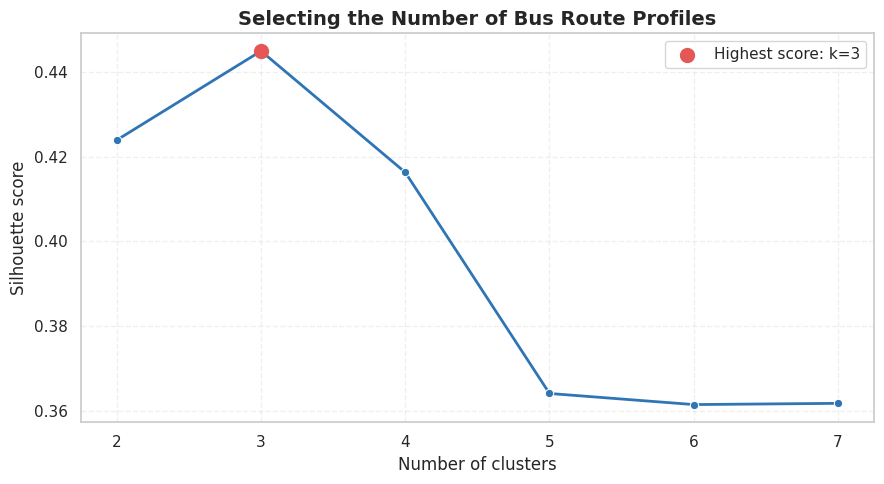

In [73]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=cluster_evaluation,
    x="Number of clusters",
    y="Silhouette score",
    marker="o",
    linewidth=2,
    color="#2F75B5",
    ax=ax
)

best_row = cluster_evaluation.loc[
    cluster_evaluation["Silhouette score"].idxmax()
]

best_k = int(best_row["Number of clusters"])
best_score = best_row["Silhouette score"]

ax.scatter(
    best_k,
    best_score,
    color="#E45756",
    s=100,
    zorder=5,
    label=f"Highest score: k={best_k}"
)

ax.set_title(
    "Selecting the Number of Bus Route Profiles",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")
ax.set_xticks(range(2, 8))
ax.legend()

ax.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Cluster-Selection Finding

The three-cluster solution achieved the highest silhouette score at
approximately **0.426**, indicating the strongest balance between within-cluster
cohesion and separation among the candidate solutions.

The four-cluster solution also performed reasonably well, with a score of
approximately **0.403**, but it did not improve the statistical separation.
Solutions containing five or more clusters produced substantially lower scores,
suggesting that they divide the routes into increasingly overlapping groups.

The three-cluster solution was therefore selected because it provides the
highest silhouette score and a relatively parsimonious set of route profiles
that can be interpreted and communicated operationally.

In [74]:
# Select the number of clusters with the highest silhouette score.
best_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["Silhouette score"].idxmax(),
        "Number of clusters"
    ]
)

best_silhouette_score = float(
    cluster_evaluation.loc[
        cluster_evaluation["Silhouette score"].idxmax(),
        "Silhouette score"
    ]
)

# Fit the final K-means model.
final_model = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = final_model.fit_predict(
    X_scaled
)

# Store the original numeric cluster assignment.
cluster_data["cluster_number"] = cluster_labels

# Create readable profile names beginning at Profile 1.
cluster_data["service_profile"] = [
    f"Profile {cluster_number + 1}"
    for cluster_number in cluster_labels
]

print("Selected number of profiles:", best_k)
print(
    "Silhouette score:",
    f"{best_silhouette_score:.3f}"
)

print("\nRoutes assigned to each profile:")

print(
    cluster_data["service_profile"]
    .value_counts()
    .sort_index()
)

Selected number of profiles: 3
Silhouette score: 0.445

Routes assigned to each profile:
service_profile
Profile 1    150
Profile 2     37
Profile 3     20
Name: count, dtype: int64


In [75]:
cluster_data[
    [
        "route_label",
        "service_profile",
        "average_service_span_hours",
        "average_trips_per_hour",
        "average_stop_events_per_trip",
        "median_trip_duration_minutes"
    ]
].head(10)

,route_label,service_profile,average_service_span_hours,average_trips_per_hour,average_stop_events_per_trip,median_trip_duration_minutes
3,747 – YUL Aéroport Montréal-Trudeau,Profile 3,24.096667,12.711218,8.163405,36.0
5,777 – Jean-Drapeau / Casino / Bonaventure,Profile 3,20.620000,10.544997,6.032797,6.0
6,767 – La Ronde / Station Jean-Drapeau,Profile 3,17.400000,11.954023,2.000000,6.0
7,439 – Express Pie-IX,Profile 1,15.340000,13.434919,29.788499,52.0
8,165 – Côte-des-Neiges,Profile 1,20.266667,10.057912,33.482181,31.0
9,67 – Saint-Michel,Profile 1,21.448333,7.966941,39.485234,45.0
10,106 – Newman,Profile 1,20.840000,7.372259,26.958913,24.0
11,51 – Édouard-Montpetit,Profile 1,17.491026,6.988522,42.512434,51.0
12,105 – Sherbrooke,Profile 3,16.881944,7.137778,18.965570,20.0
13,141 – Jean-Talon Est,Profile 1,18.845238,6.433523,49.181479,46.0


In [76]:
cluster_profile = (
    cluster_data
    .groupby(
        "service_profile",
        as_index=False
    )
    .agg(
        number_of_routes=(
            "route_id",
            "nunique"
        ),
        average_service_span_hours=(
            "average_service_span_hours",
            "mean"
        ),
        average_trips_per_hour=(
            "average_trips_per_hour",
            "mean"
        ),
        average_stop_events_per_trip=(
            "average_stop_events_per_trip",
            "mean"
        ),
        median_trip_duration_minutes=(
            "median_trip_duration_minutes",
            "median"
        ),
        average_scheduled_trips=(
            "average_scheduled_trips",
            "mean"
        )
    )
    .sort_values(
        "service_profile"
    )
    .reset_index(drop=True)
)

cluster_profile.style.format({
    "number_of_routes": "{:,.0f}",
    "average_service_span_hours": "{:.1f}",
    "average_trips_per_hour": "{:.2f}",
    "average_stop_events_per_trip": "{:.1f}",
    "median_trip_duration_minutes": "{:.1f}",
    "average_scheduled_trips": "{:.1f}"
}).hide(axis="index").set_caption(
    "Operational Characteristics of the Three Bus Route Profiles"
)

service_profile,number_of_routes,average_service_span_hours,average_trips_per_hour,average_stop_events_per_trip,median_trip_duration_minutes,average_scheduled_trips
Profile 1,150,17.6,4.04,36.6,35.6,74.8
Profile 2,37,6.8,2.24,54.8,49.0,13.9
Profile 3,20,16.7,5.93,9.9,13.2,106.5


In [77]:
cluster_profile["share_of_bus_routes_percentage"] = (
    100
    * cluster_profile["number_of_routes"]
    / cluster_profile["number_of_routes"].sum()
)

cluster_profile.style.format({
    "number_of_routes": "{:,.0f}",
    "share_of_bus_routes_percentage": "{:.1f}%",
    "average_service_span_hours": "{:.1f}",
    "average_trips_per_hour": "{:.2f}",
    "average_stop_events_per_trip": "{:.1f}",
    "median_trip_duration_minutes": "{:.1f}",
    "average_scheduled_trips": "{:.1f}"
}).hide(axis="index").set_caption(
    "Operational Characteristics of the Three Bus Route Profiles"
)

service_profile,number_of_routes,average_service_span_hours,average_trips_per_hour,average_stop_events_per_trip,median_trip_duration_minutes,average_scheduled_trips,share_of_bus_routes_percentage
Profile 1,150,17.6,4.04,36.6,35.6,74.8,72.5%
Profile 2,37,6.8,2.24,54.8,49.0,13.9,17.9%
Profile 3,20,16.7,5.93,9.9,13.2,106.5,9.7%


In [78]:
fig = px.scatter(
    cluster_data,
    x="average_service_span_hours",
    y="average_trips_per_hour",
    size="average_scheduled_trips",
    color="service_profile",
    hover_name="route_label",
    hover_data={
        "average_service_span_hours": ":.1f",
        "average_trips_per_hour": ":.2f",
        "average_scheduled_trips": ":.1f",
        "average_stop_events_per_trip": ":.1f",
        "median_trip_duration_minutes": ":.1f",
        "route_id": False,
        "route_short_name": False,
        "route_long_name": False,
        "cluster_number": False
    },
    title="Operational Profiles of STM Bus Routes",
    labels={
        "average_service_span_hours":
            "Average service span (hours)",

        "average_trips_per_hour":
            "Average scheduled trips per service hour",

        "average_scheduled_trips":
            "Average scheduled trip volume",

        "average_stop_events_per_trip":
            "Average stop events per trip",

        "median_trip_duration_minutes":
            "Median trip duration (minutes)",

        "service_profile":
            "Bus route profile"
    },
    color_discrete_map={
        "Profile 1": "#2F75B5",
        "Profile 2": "#E45756",
        "Profile 3": "#59A14F"
    },
    category_orders={
        "service_profile": [
            "Profile 1",
            "Profile 2",
            "Profile 3"
        ]
    },
    size_max=35,
    height=650
)

fig.update_traces(
    marker={
        "opacity": 0.75,
        "line": {
            "width": 0.7,
            "color": "white"
        }
    }
)

fig.update_layout(
    template="plotly_white",
    title={
        "x": 0.5,
        "xanchor": "center"
    },
    legend_title_text="Bus route profile",
    margin={
        "l": 40,
        "r": 40,
        "t": 70,
        "b": 40
    }
)

fig.show()

Cluster Visualization Findings

The three profiles occupy distinguishable—but partially overlapping—regions of
the service-span and service-intensity space.

- **Profile 2** is concentrated among routes operating over shorter service
  spans, generally with fewer than three scheduled trips per service hour.
  This group appears to represent limited or lower-intensity services.

- **Profile 1** contains the largest concentration of routes. Most operate for
  approximately 13 to 22 hours and provide around two to six scheduled trips
  per service hour. This profile appears to represent the principal regular bus
  service pattern.

- **Profile 3** contains a smaller and more dispersed group. Several routes in
  this profile have unusually high service intensity and larger scheduled trip
  volumes, while others differ from the main network according to stop counts
  or trip duration.

The partial overlap between profiles is consistent with the moderate silhouette
score of 0.426. Bus-route characteristics vary along a continuum rather than
forming completely isolated categories.

In [79]:
from pathlib import Path

output_directory = Path("tableau_exports")
output_directory.mkdir(exist_ok=True)

route_ranking.to_csv(
    output_directory / "stm_route_summary.csv",
    index=False
)

weekday_weekend.to_csv(
    output_directory / "stm_weekday_weekend_comparison.csv",
    index=False
)

cluster_data.to_csv(
    output_directory / "stm_route_service_profiles.csv",
    index=False
)

stop_map_data.to_csv(
    output_directory / "stm_stop_locations.csv",
    index=False
)

quality_results.to_csv(
    output_directory / "stm_data_quality_report.csv",
    index=False
)

print("Tableau-ready files exported successfully.")

Tableau-ready files exported successfully.


In [82]:
from google.colab import drive

drive.mount("/content/drive")

from pathlib import Path

shared_folder = Path(
    "/content/drive/MyDrive/montreal-transit-service-analysis/tableau_exports"
)

shared_folder.mkdir(
    parents=True,
    exist_ok=True
)

weekday_weekend.to_csv(
    shared_folder / "weekday_weekend_dashboard.csv",
    index=False
)

stop_map_data.to_csv(
    shared_folder / "stop_map_dashboard.csv",
    index=False
)

service_comparison.to_csv(
    shared_folder / "service_comparison_dashboard.csv",
    index=False
)

print("Files saved to:", shared_folder)

Mounted at /content/drive
Files saved to: /content/drive/MyDrive/montreal-transit-service-analysis/tableau_exports


### Key Conclusions

1. Scheduled service is concentrated among the métro lines, the 747 airport
   service and a small group of high-volume bus routes.
2. Routes with similar operating spans can have substantially different
   scheduled service intensities, demonstrating that operating span alone is
   not an adequate comparison metric.
3. The bus network contains three moderately separated operating profiles:
   regular all-day services, limited-span lower-intensity services, and a
   smaller group of intensive or specialized routes.

### Recommendations

1. Monitor routes against profile-specific benchmarks instead of applying one
   network-wide service standard.
2. Combine the schedule indicators with actual ridership, reliability,
   crowding and rider-feedback data before recommending service changes.
3. Prioritize high-volume and high-intensity routes for reliability monitoring
   because disruptions to these services may affect a large share of scheduled
   network activity.